In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
df = pd.read_csv('../data/IT-salary-Argentina.csv', header=9)
df.head()

,Unnamed: 0,donde_estas_trabajando,dedicacion,tipo_de_contrato,ultimo_salario_mensual_o_retiro_bruto_en_pesos_argentinos,ultimo_salario_mensual_o_retiro_neto_en_pesos_argentinos,pagos_en_dolares,si_tu_sueldo_esta_dolarizado_cual_fue_el_ultimo_valor_del_dolar_que_tomaron,recibis_algun_tipo_de_bono,a_que_esta_atado_el_bono,...,salir_o_seguir_contestando_sobre_las_guardias,tenes_guardias,cuanto_cobras_por_guardia,aclara_el_numero_que_ingresaste_en_el_campo_anterior,tengo_edad,genero,habias_respondido_nuestra_encuesta_en_ediciones_anteriores,sueldo_dolarizado,seniority,_sal
0,0,Ciudad Autónoma de Buenos Aires,Part-Time,Staff (planta permanente),6500000.0,5800000.0,Cobro parte del salario en dólares,NaN,De uno a tres sueldos,Performance de la compañía,...,NaN,NaN,NaN,NaN,45,Hombre Cis,Sí,True,Senior,6500000.0
1,1,Ciudad Autónoma de Buenos Aires,Full-Time,Contractor,12700000.0,10200000.0,Cobro todo el salario en dólares,NaN,Un sueldo,Performance de la compañía,...,Terminar encuesta,No,0.0,Bruto,32,Mujer Cis,Sí,True,Senior,12700000.0
2,2,Córdoba,Full-Time,Staff (planta permanente),3952805.0,3137662.0,Cobro parte del salario en dólares,985,No,No recibo bono,...,NaN,NaN,NaN,NaN,29,Hombre Cis,Sí,True,Semi-Senior,3952805.0
3,3,Ciudad Autónoma de Buenos Aires,Part-Time,Staff (planta permanente),1606000.0,1360000.0,Cobro parte del salario en dólares,1004,No,No recibo bono,...,NaN,NaN,NaN,NaN,25,Hombre Cis,Sí,True,Semi-Senior,1606000.0
4,4,Córdoba,Full-Time,Tercerizado (trabajo a través de consultora o ...,1325301.0,NaN,Cobro parte del salario en dólares,NaN,No,No recibo bono,...,Terminar encuesta,NaN,NaN,NaN,22,Hombre Cis,Sí,True,Senior,1325301.0


In [11]:
df['salario_bruto'] = pd.to_numeric(
    df['ultimo_salario_mensual_o_retiro_bruto_en_pesos_argentinos'], 
    errors='coerce'
)

In [12]:
print("Filas y columnas:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

Filas y columnas: (5196, 51)

Columnas:
['Unnamed: 0', 'donde_estas_trabajando', 'dedicacion', 'tipo_de_contrato', 'ultimo_salario_mensual_o_retiro_bruto_en_pesos_argentinos', 'ultimo_salario_mensual_o_retiro_neto_en_pesos_argentinos', 'pagos_en_dolares', 'si_tu_sueldo_esta_dolarizado_cual_fue_el_ultimo_valor_del_dolar_que_tomaron', 'recibis_algun_tipo_de_bono', 'a_que_esta_atado_el_bono', 'tuviste_actualizaciones_de_tus_ingresos_laborales_durante_2024', 'de_que_fue_el_ajuste_total_acumulado', 'en_que_mes_fue_el_ultimo_ajuste', 'como_consideras_que_estan_tus_ingresos_laborales_comparados_con_el_semestre_anterior', 'contas_con_beneficios_adicionales', 'que_tan_conforme_estas_con_tus_ingresos_laborales', 'estas_buscando_trabajo', 'pluriempleo', 'trabajo_de', 'anos_de_experiencia', 'antiguedad_en_la_empresa_actual', 'anos_en_el_puesto_actual', 'cuantas_personas_tenes_a_cargo', 'plataformas_que_utilizas_en_tu_puesto_actual', 'lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puest

In [13]:
print(df.shape)
print("\nColumnas:")
for col in df.columns.tolist():
    print(col)
    

(5196, 51)

Columnas:
Unnamed: 0
donde_estas_trabajando
dedicacion
tipo_de_contrato
ultimo_salario_mensual_o_retiro_bruto_en_pesos_argentinos
ultimo_salario_mensual_o_retiro_neto_en_pesos_argentinos
pagos_en_dolares
si_tu_sueldo_esta_dolarizado_cual_fue_el_ultimo_valor_del_dolar_que_tomaron
recibis_algun_tipo_de_bono
a_que_esta_atado_el_bono
tuviste_actualizaciones_de_tus_ingresos_laborales_durante_2024
de_que_fue_el_ajuste_total_acumulado
en_que_mes_fue_el_ultimo_ajuste
como_consideras_que_estan_tus_ingresos_laborales_comparados_con_el_semestre_anterior
contas_con_beneficios_adicionales
que_tan_conforme_estas_con_tus_ingresos_laborales
estas_buscando_trabajo
pluriempleo
trabajo_de
anos_de_experiencia
antiguedad_en_la_empresa_actual
anos_en_el_puesto_actual
cuantas_personas_tenes_a_cargo
plataformas_que_utilizas_en_tu_puesto_actual
lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual
frameworksherramientas_y_librerias_que_utilices_en_tu_puesto_actual
bases_de_datos


In [14]:
# The most important columns for the analysis are those related to the job, salary and type of employment (remote, onsite or hybrid), so we will focus on those for the next steps of the exploratory analysis.
columnas_clave = [
    'donde_estas_trabajando',
    'dedicacion',
    'tipo_de_contrato',
    'ultimo_salario_mensual_o_retiro_bruto_en_pesos_argentinos',
    'pagos_en_dolares',
    'anos_de_experiencia',
    'antiguedad_en_la_empresa_actual',
    'seniority',
    'trabajo_de'
]

df[columnas_clave].head(10)

,donde_estas_trabajando,dedicacion,tipo_de_contrato,ultimo_salario_mensual_o_retiro_bruto_en_pesos_argentinos,pagos_en_dolares,anos_de_experiencia,antiguedad_en_la_empresa_actual,seniority,trabajo_de
0,Ciudad Autónoma de Buenos Aires,Part-Time,Staff (planta permanente),6500000.00,Cobro parte del salario en dólares,20,14,Senior,Manager / Director
1,Ciudad Autónoma de Buenos Aires,Full-Time,Contractor,12700000.00,Cobro todo el salario en dólares,12,3,Senior,Technical Leader
2,Córdoba,Full-Time,Staff (planta permanente),3952805.00,Cobro parte del salario en dólares,3,3,Semi-Senior,Data Engineer
3,Ciudad Autónoma de Buenos Aires,Part-Time,Staff (planta permanente),1606000.00,Cobro parte del salario en dólares,5,2,Semi-Senior,Developer
4,Córdoba,Full-Time,Tercerizado (trabajo a través de consultora o ...,1325301.00,Cobro parte del salario en dólares,6,4,Senior,SysAdmin / DevOps / SRE
5,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),2670205.00,Cobro parte del salario en dólares,28,2,Senior,Technical Support
6,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),4000000.00,Cobro todo el salario en dólares,25,3,Senior,Consultant
7,Córdoba,Full-Time,Staff (planta permanente),4200000.00,Cobro parte del salario en dólares,15,1,Senior,Manager / Director
8,Buenos Aires,Full-Time,Freelance,3000000.00,Mi sueldo está dolarizado (pero cobro en moned...,18,8,Senior,Architect
9,Buenos Aires,Full-Time,Staff (planta permanente),3953142.06,Mi sueldo está dolarizado (pero cobro en moned...,15,5,Senior,Data Engineer


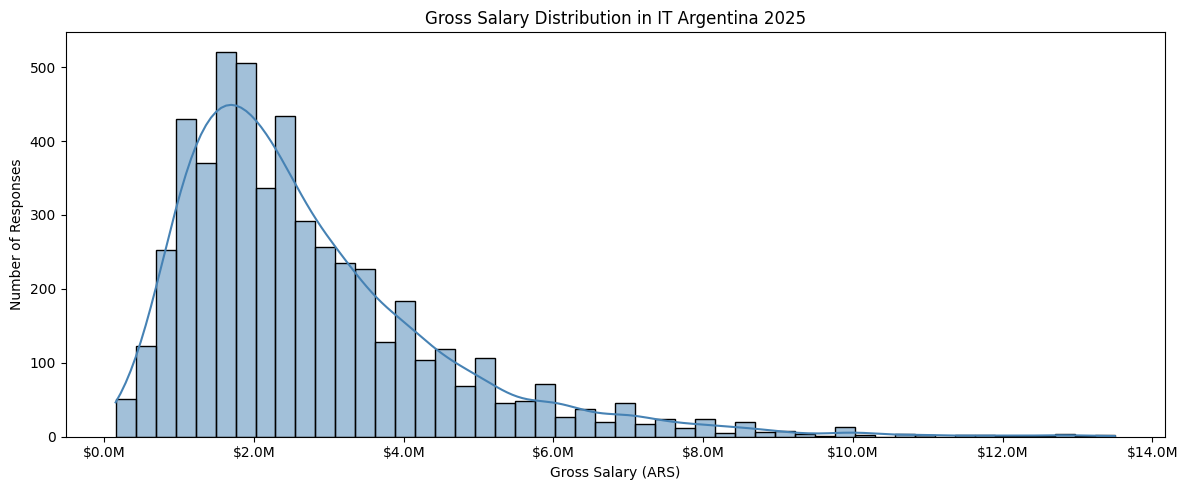

In [15]:
plt.figure(figsize=(12, 5))
sns.histplot(df['salario_bruto'], bins=50, kde=True, color='steelblue')
plt.title('Gross Salary Distribution in IT Argentina 2025')
plt.xlabel('Gross Salary (ARS)')
plt.ylabel('Number of Responses')
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M')
)
plt.tight_layout()
plt.savefig('../images/distribucion_salarios.png', dpi=150)
plt.show()

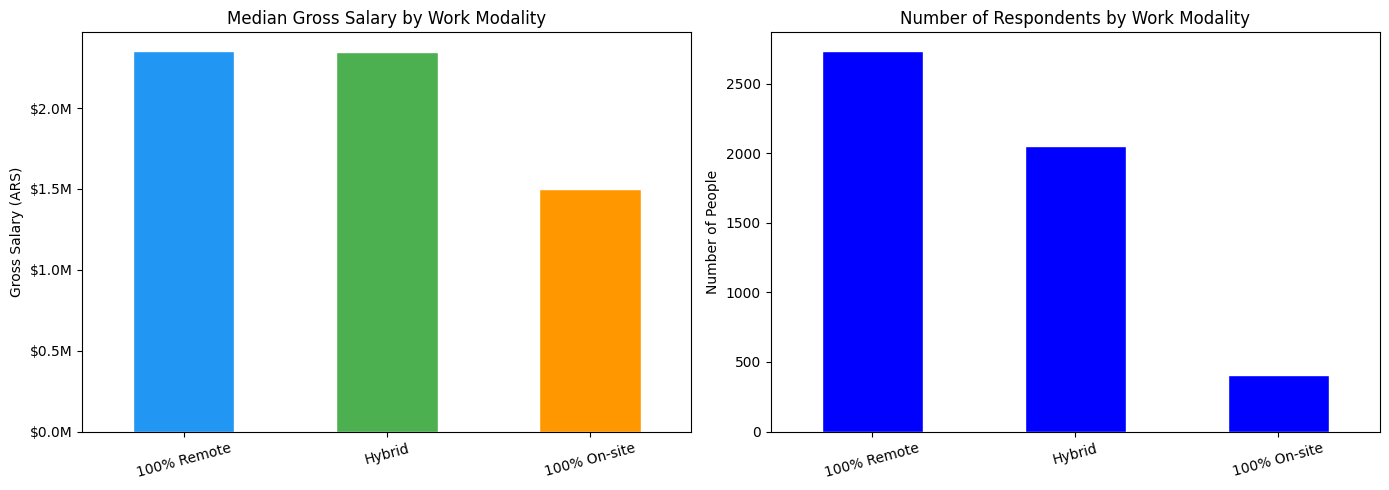

<Figure size 640x480 with 0 Axes>

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphic 1: Median salary by modality
colores = ['#2196F3', '#4CAF50', '#FF9800']

salario_modalidad = df.groupby('modalidad_de_trabajo')['salario_bruto'].median().sort_values(ascending=False)
salario_modalidad.plot(kind='bar', ax=axes[0], color=colores, edgecolor='white')
axes[0].set_title('Median Gross Salary by Work Modality')
axes[0].set_xlabel('')
axes[0].set_ylabel('Gross Salary (ARS)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M'))
axes[0].set_xticklabels(['100% Remote', 'Hybrid', '100% On-site'], rotation=15)

# Graphic 2: number of respondents by modality
conteo = df['modalidad_de_trabajo'].value_counts()
conteo.plot(kind='bar', ax=axes[1], color="blue", edgecolor='white')
axes[1].set_title('Number of Respondents by Work Modality')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of People')
axes[1].set_xticklabels(['100% Remote', 'Hybrid', '100% On-site'], rotation=15)

plt.tight_layout()
plt.savefig('../images/salario_por_modalidad.png', dpi=150)
plt.show()

plt.tight_layout()
plt.savefig('../images/salario_por_modalidad.png', dpi=150)
plt.show()

In [ ]:
salario_seniority = df.groupby('seniority')['salario_bruto'].median().reindex(['Junior', 'Semi-Senior', 'Senior'])
print(salario_seniority)

seniority
Junior         1300000.0
Semi-Senior    2000000.0
Senior         3000000.0
Name: salario_bruto, dtype: float64


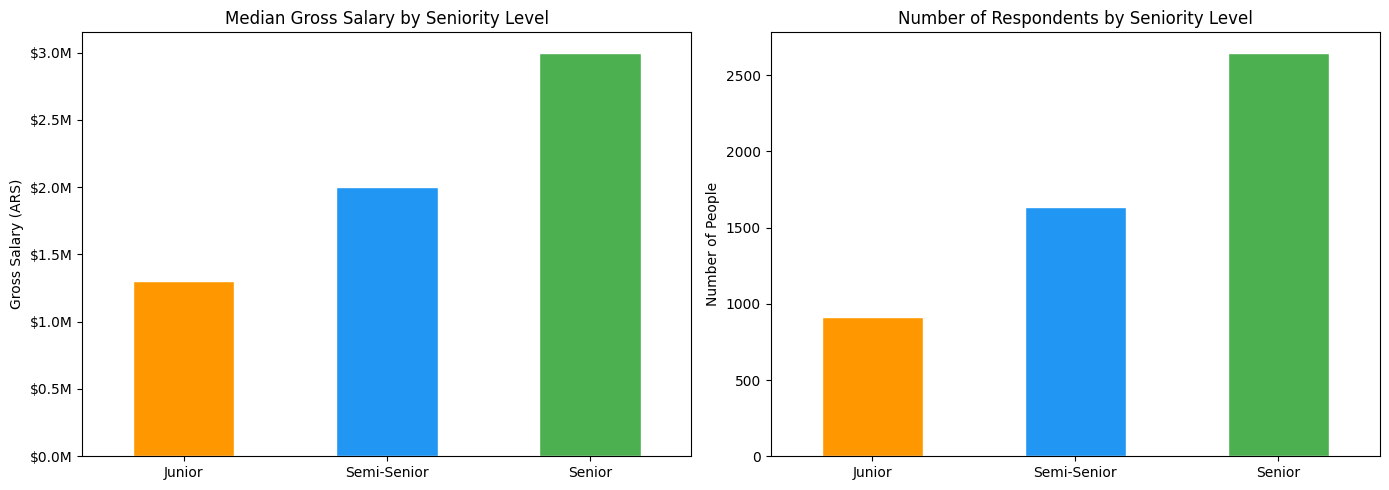

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores_seniority = ['#FF9800', '#2196F3', '#4CAF50']

# Graphic 1: median salary by seniority
salario_seniority.plot(kind='bar', ax=axes[0], color=colores_seniority, edgecolor='white')
axes[0].set_title('Median Gross Salary by Seniority Level')
axes[0].set_xlabel('')
axes[0].set_ylabel('Gross Salary (ARS)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M'))
axes[0].set_xticklabels(['Junior', 'Semi-Senior', 'Senior'], rotation=0)

# Graphic 2: Number of people by seniority
conteo_seniority = df['seniority'].value_counts().reindex(['Junior', 'Semi-Senior', 'Senior'])
conteo_seniority.plot(kind='bar', ax=axes[1], color=colores_seniority, edgecolor='white')
axes[1].set_title('Number of Respondents by Seniority Level')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of People')
axes[1].set_xticklabels(['Junior', 'Semi-Senior', 'Senior'], rotation=0)

plt.tight_layout()
plt.savefig('../images/salario_por_seniority.png', dpi=150)
plt.show()

In [ ]:
# filtering roles with more than 80 responses
roles_principales = df['trabajo_de'].value_counts()
roles_principales = roles_principales[roles_principales >= 80].index

df_roles = df[df['trabajo_de'].isin(roles_principales)]

# Median salary by role, in order from highest to lowest
salario_roles = df_roles.groupby('trabajo_de')['salario_bruto'].median().sort_values(ascending=True)
print(salario_roles)

trabajo_de
HelpDesk                     1179000.000
QA / Tester                  1675000.000
Networking                   1756997.000
UX Designer                  1880000.000
BI Analyst / Data Analyst    1900000.000
Business Analyst             2000000.000
Consultant                   2100000.000
Developer                    2160000.000
SysAdmin / DevOps / SRE      2247014.000
Infosec                      2500000.000
Data Engineer                2526962.500
Data Scientist               2620000.000
Manager / Director           3413960.015
Technical Leader             3500000.000
Architect                    4000000.000
Name: salario_bruto, dtype: float64


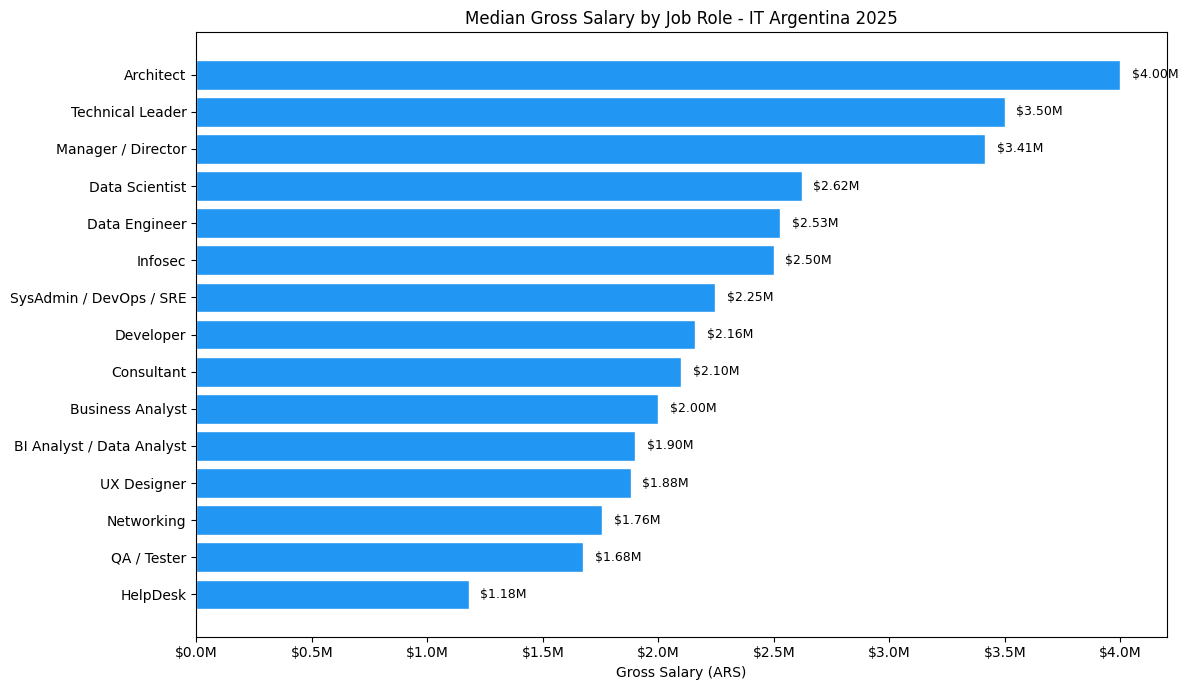

In [ ]:
plt.figure(figsize=(12, 7))

colores_roles = ['#2196F3' for _ in salario_roles.index]

bars = plt.barh(salario_roles.index, salario_roles.values, color=colores_roles, edgecolor='white')

plt.title('Median Gross Salary by Job Role - IT Argentina 2025')
plt.xlabel('Gross Salary (ARS)')
plt.ylabel('')
plt.xaxis_set = plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M')
)

# Add the values next to each bar
for bar, val in zip(bars, salario_roles.values):
    plt.text(val + 50_000, bar.get_y() + bar.get_height()/2,
             f'${val/1_000_000:.2f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../images/salario_por_rol.png', dpi=150)
plt.show()